# RF Regression for our "numeric" dataset

### Note: You do not necessarily have to do a test/ training split in RF because OOB error can be a good proxy for out-of-sample MSE
### That said, we did do a test / training split here to get an apples-to-apples comparison to the other models we used

In [2]:
# chatGPT typed this out so i didn't have to look it all up

# === Core ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt

# === Model Selection & Evaluation ===
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

# === Tree-Based Model ===
from sklearn.ensemble import RandomForestRegressor

# === Utility ===
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display


In [3]:
#==== SELECT YOUR DATA SOURCE ====#

# url = "https://raw.githubusercontent.com/AHMerrill/housing-project/main/housing_data_numeric_NLP.csv"

url = 'housing_data_with_neighborhoods_encoded.csv'

In [4]:
housing_rf = pd.read_csv(url) # your transformed file name here
housing_rf

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,planning_area_name_WEST AUSTIN NEIGHBORHOOD GROUP,planning_area_name_WEST CONGRESS,planning_area_name_WEST OAK HILL,planning_area_name_WEST UNIVERSITY,planning_area_name_WESTGATE,planning_area_name_WINDSOR HILLS,planning_area_name_WINDSOR PARK,planning_area_name_WINDSOR ROAD,planning_area_name_WOOTEN,planning_area_name_ZILKER
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.850,40,...,False,False,False,False,False,False,False,False,False,False
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.000,31,...,False,False,False,False,False,False,False,False,False,False
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.000,21,...,False,False,False,False,False,False,False,False,False,False
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.000,20,...,False,False,False,False,False,False,False,False,False,False
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.000,10,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6784,30.329531,-97.738258,1.98,4,False,True,False,False,647.877,28,...,False,False,False,False,False,False,False,False,False,False
6785,30.326372,-97.734268,1.98,1,False,True,False,False,445.000,28,...,False,False,False,False,False,False,False,False,False,False
6786,30.327656,-97.734779,1.98,1,False,True,False,False,400.000,22,...,False,False,False,False,False,False,False,False,False,False
6787,30.240223,-97.772835,1.98,2,True,True,True,True,550.000,32,...,False,False,False,False,False,False,False,False,False,False


In [5]:
#==== THIS MAY NOT BE NECESSARY IF logLatestPrice is already in the dataset ====#
housing_rf['logLatestPrice'] = np.log(housing_rf['latestPrice'])
housing_rf

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,planning_area_name_WEST CONGRESS,planning_area_name_WEST OAK HILL,planning_area_name_WEST UNIVERSITY,planning_area_name_WESTGATE,planning_area_name_WINDSOR HILLS,planning_area_name_WINDSOR PARK,planning_area_name_WINDSOR ROAD,planning_area_name_WOOTEN,planning_area_name_ZILKER,logLatestPrice
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.850,40,...,False,False,False,False,False,False,False,False,False,6.533571
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.000,31,...,False,False,False,False,False,False,False,False,False,6.013715
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.000,21,...,False,False,False,False,False,False,False,False,False,5.293305
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.000,20,...,False,False,False,False,False,False,False,False,False,5.991465
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.000,10,...,False,False,False,False,False,False,False,False,False,5.480639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6784,30.329531,-97.738258,1.98,4,False,True,False,False,647.877,28,...,False,False,False,False,False,False,False,False,False,6.473701
6785,30.326372,-97.734268,1.98,1,False,True,False,False,445.000,28,...,False,False,False,False,False,False,False,False,False,6.098074
6786,30.327656,-97.734779,1.98,1,False,True,False,False,400.000,22,...,False,False,False,False,False,False,False,False,False,5.991465
6787,30.240223,-97.772835,1.98,2,True,True,True,True,550.000,32,...,False,False,False,False,False,False,False,False,False,6.309918


In [6]:
#from the sklearn documentation
housing_train, housing_test = train_test_split(housing_rf,test_size = .3, train_size = .7, random_state = 123, shuffle = True)


# RF for latestPrice

In [7]:
# define the predictors and the target
predictors = housing_train.drop(columns = ['latestPrice','logLatestPrice'])
target = housing_train['latestPrice']

X_train = predictors
y_train = target

# set up cross validation for hyperparameter tuning (estimators, max_feature selection, depth, etc.)
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

param_grid = {
    'n_estimators': [100, 300],
    'max_features': ['sqrt', 0.3],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}


rf_model = RandomForestRegressor(random_state=123, oob_score=True, bootstrap=True)

# this will train the models on the above grid
grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1, # use all the cores
    refit=True # refit it and save it as the best model
)

# here's the model fit
grid.fit(X_train, y_train)

# here's where it's saved
best_rf = grid.best_estimator_

# pulling out oob error
rf_oob_predictions = best_rf.oob_prediction_

# training oob error
rf_oob_rmse = np.sqrt(mean_squared_error(y_train, rf_oob_predictions))
print(f'RF OOB RMSE: ${rf_oob_rmse*1000:,.02f}')

python(94027) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94028) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94029) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94030) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94031) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94032) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94033) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94034) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94035) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94036) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


RF OOB RMSE: $174,562.72


In [8]:
feature_imp = pd.DataFrame(
    {'importance': best_rf.feature_importances_},
    index=predictors.columns
)

feature_imp = feature_imp.sort_values(by='importance', ascending=False)
display(feature_imp)


,importance
livingAreaSqFt,0.138300
log_livingAreaSqFt,0.135154
numOfBathrooms,0.090581
latitude,0.051013
zipcode78704,0.042718
...,...
planning_area_name_NORTH LAMAR,0.000009
planning_area_name_HERITAGE HILLS,0.000008
planning_area_name_SWEETBRIAR,0.000006
planning_area_name_WEST CONGRESS,0.000006


RF Test RMSE: $151,790.48


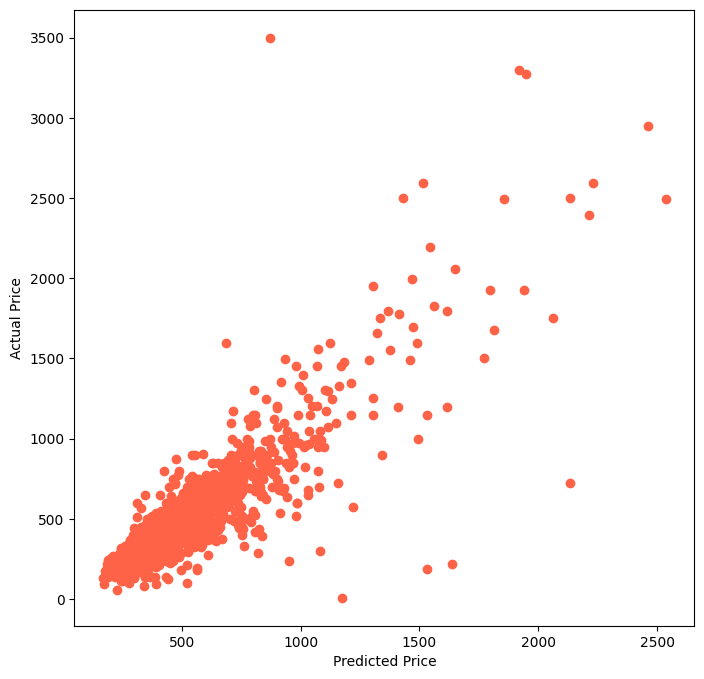

In [9]:
# used chatGPT to adapt from the homework

# Define y_test and X_test
y_test = housing_test['latestPrice']
X_test = housing_test[predictors.columns]

# Predict using the best random forest model
y_hat_rf = best_rf.predict(X_test)

# Plot predicted vs actual prices
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_hat_rf, y_test, color='tomato')
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Actual Price')

# Calculate MSE
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_hat_rf))
print(f'RF Test RMSE: ${rf_test_rmse * 1000:,.02f}')


# RF for logLatestPrice:

In [10]:
# define the predictors and the target
predictors = housing_train.drop(columns=['latestPrice', 'logLatestPrice'])
target = housing_train['logLatestPrice']

X_train = predictors
y_train = target

# set up cross validation for hyperparameter tuning (estimators, max_feature selection, depth, etc.)
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

param_grid = {
    'n_estimators': [100, 300],
    'max_features': ['sqrt', 0.3],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestRegressor(random_state=123, oob_score=True, bootstrap=True)

# train the models on the above grid
grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    refit=True
)

# model fit
grid.fit(X_train, y_train)

# best model
best_rf = grid.best_estimator_

# oob predictions (these are still on log scale)
rf_oob_predictions = best_rf.oob_prediction_

# training oob error (still on log scale)
rf_oob_rmse = np.sqrt(mean_squared_error(np.exp(y_train), np.exp(rf_oob_predictions)))
print(f'RF OOB RMSE: ${rf_oob_rmse * 1000:,.02f}')


RF OOB RMSE: $185,268.06


In [11]:
feature_imp = pd.DataFrame(
    {'importance': best_rf.feature_importances_},
    index=predictors.columns
)

feature_imp = feature_imp.sort_values(by='importance', ascending=False)
display(feature_imp)

,importance
livingAreaSqFt,0.145137
log_livingAreaSqFt,0.138226
avgSchoolRating,0.067074
avgSchoolRating_sq,0.066659
latitude,0.058481
...,...
planning_area_name_SWEETBRIAR,0.000027
planning_area_name_HERITAGE HILLS,0.000026
planning_area_name_WEST CONGRESS,0.000014
planning_area_name_WEST UNIVERSITY,0.000007


RF Test RMSE: $160,189.33


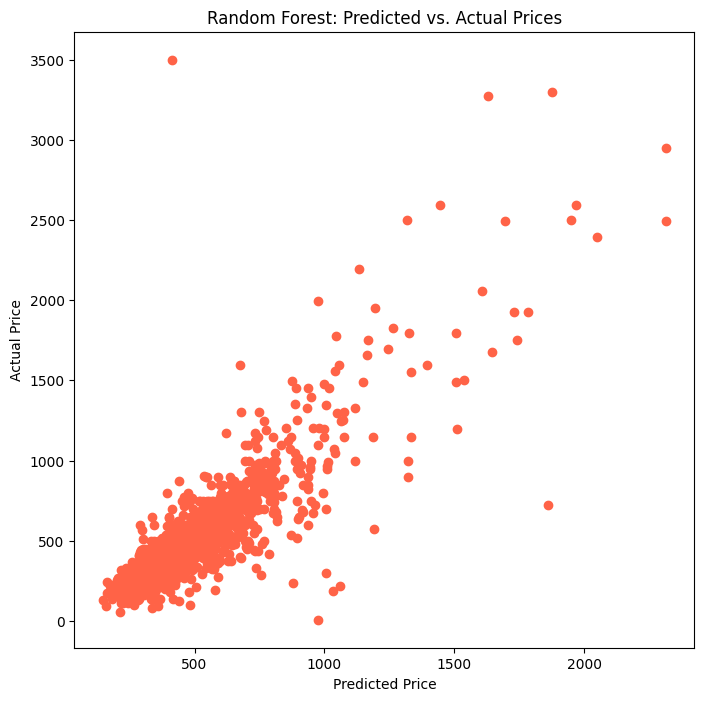

In [12]:
# Define y_test and X_test
y_test = housing_test['logLatestPrice']
X_test = housing_test[predictors.columns]

# Predict using the best random forest model
y_hat_rf = best_rf.predict(X_test)

# Plot predicted vs actual prices (converted to original price scale)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(np.exp(y_hat_rf), np.exp(y_test), color='tomato')
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Actual Price')
ax.set_title('Random Forest: Predicted vs. Actual Prices')

# Calculate MSE in dollar terms
rf_test_rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_hat_rf)))
print(f'RF Test RMSE: ${rf_test_rmse * 1000:,.02f}')
